In [32]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from pha_lib import io
from pha_lib.discharges import detect_injections, InjectionDetectionConfig
from pha_lib.fit import fit_injection
from pha_lib.model import Discharge, TimeTrace, Injection, FitResult
from pha_lib.plotting import plot_timetrace_with_injections, plot_injection_fit
from pha_lib.timetrace import integrate_energy_window

plt.rcParams["figure.dpi"] = 120

In [45]:
@dataclass
class BigEyeConfig:
    line_energy_eV: float = 6660.0
    half_window_eV: float = 60
    n_points: int = 3
    adaptive_min_points: int = 3
    adaptive_max_points: int = 15


def plot_all_injections_one_graph(
    trace: TimeTrace,
    injections: Sequence[Injection],
    normalize_to_start: bool = False,
    alpha: float = 0.9,
    x_max_offset: float | None = None,
    ax: plt.Axes | None = None,
    title: str | None = None,
) -> plt.Axes:
    """Overlay points of all injections on one graph, aligned by start frame."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    fn = trace.frame_numbers
    y = trace.values
    plotted = 0
    max_offset_seen = 0.0

    for inj in injections:
        mask = (fn >= inj.start_frame) & (fn <= inj.finish_frame)
        if not np.any(mask):
            continue

        x_local = fn[mask].astype(float) - float(inj.start_frame)
        y_local = y[mask].astype(float)
        if normalize_to_start:
            y_local = y_local - y_local[0]

        if x_local.size > 0:
            max_offset_seen = max(max_offset_seen, float(np.max(x_local)))

        ax.plot(
            x_local,
            y_local,
            "o-",
            ms=5.5,
            lw=2.4,
            alpha=alpha,
            label=f"inj #{inj.injection_no}",
        )
        plotted += 1

    lo, hi = trace.energy_window_eV
    ax.set_title(title or f"All injections overlay (ch {trace.channel_id}, N={plotted}, window [{lo:.0f}, {hi:.0f}] eV)")
    ax.set_xlabel("frame offset from injection start")
    ax.set_ylabel("events" + (" (delta from start)" if normalize_to_start else ""))

    if x_max_offset is None:
        x_max_offset = max_offset_seen
    x_hi = max(float(x_max_offset), max_offset_seen, 1.0)
    ax.set_xlim(0, x_hi)

    # Denser, more readable grid and tick marks on both axes.
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=16, integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.65, linewidth=1.0)
    ax.grid(which="minor", alpha=0.30, linestyle=":", linewidth=0.8)

    if plotted > 0:
        ax.legend(loc="best", fontsize=9, ncol=2, framealpha=0.9)

    return ax


def plot_injections_across_discharges(
    results_by_discharge: dict[str, dict],
    channel_id: int = 2,
    injection_numbers: Sequence[int] | None = None,
    normalize_to_start: bool = False,
    ax: plt.Axes | None = None,
    title: str | None = None,
):
    """Overlay injections across multiple discharges.

    Visual encoding:
    - discharge -> base color + marker shape + line style
    - injections within one discharge -> shades of that discharge color
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(12, 8))

    marker_cycle = ["o", "s", "^", "D", "v", "P", "X", "<", ">", "h", "*"]
    linestyle_cycle = ["-", "--", "-.", ":"]

    # Collect all available injection numbers for this channel.
    all_inj_numbers: set[int] = set()
    for r in results_by_discharge.values():
        injs = r["detections"].get(channel_id, [])
        all_inj_numbers.update(int(i.injection_no) for i in injs)

    if injection_numbers is None:
        inj_numbers = sorted(all_inj_numbers)
    else:
        inj_numbers = [int(n) for n in injection_numbers]

    if not inj_numbers:
        ax.set_title("No injections to plot")
        return ax

    # One base color per discharge.
    base_cmap = plt.get_cmap("tab10" if len(results_by_discharge) <= 10 else "tab20")
    discharge_names = list(results_by_discharge.keys())
    base_color_by_discharge = {
        name: base_cmap(i % base_cmap.N)
        for i, name in enumerate(discharge_names)
    }

    def _shade_from_base(base_rgba, level: float):
        """Blend base color with white: lower level -> paler shade."""
        level = float(np.clip(level, 0.0, 1.0))
        r, g, b, a = base_rgba
        return (
            1.0 - (1.0 - r) * level,
            1.0 - (1.0 - g) * level,
            1.0 - (1.0 - b) * level,
            a,
        )

    x_max = 1.0
    shade_by_discharge: dict[str, dict[int, tuple[float, float, float, float]]] = {}
    inj_present_by_discharge: dict[str, list[int]] = {}

    for d_idx, (d_name, r) in enumerate(results_by_discharge.items()):
        marker = marker_cycle[d_idx % len(marker_cycle)]
        linestyle = linestyle_cycle[d_idx % len(linestyle_cycle)]
        base_color = base_color_by_discharge[d_name]

        trace = r["traces"].get(channel_id)
        if trace is None:
            continue

        fn = trace.frame_numbers
        y = trace.values
        injections = r["detections"].get(channel_id, [])
        inj_map = {int(inj.injection_no): inj for inj in injections}

        # Injection order within this discharge defines shade intensity.
        inj_present = [n for n in inj_numbers if n in inj_map]
        inj_present_by_discharge[d_name] = inj_present
        if not inj_present:
            continue

        n_local = len(inj_present)
        local_shades: dict[int, tuple[float, float, float, float]] = {}
        for k, inj_no in enumerate(inj_present):
            # From paler to saturated for later injections.
            level = 0.35 if n_local == 1 else 0.35 + 0.65 * (k / (n_local - 1))
            local_shades[inj_no] = _shade_from_base(base_color, level)
        shade_by_discharge[d_name] = local_shades

        for inj_no in inj_present:
            inj = inj_map[inj_no]

            mask = (fn >= inj.start_frame) & (fn <= inj.finish_frame)
            if not np.any(mask):
                continue

            x_local = fn[mask].astype(float) - float(inj.start_frame)
            y_local = y[mask].astype(float)
            if normalize_to_start:
                y_local = y_local - y_local[0]

            x_max = max(x_max, float(np.max(x_local)))

            ax.plot(
                x_local,
                y_local,
                marker=marker,
                linestyle=linestyle,
                color=local_shades[inj_no],
                lw=2.4,
                ms=6.0,
                alpha=0.95,
            )

    ax.set_xlim(0, x_max)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=16, integer=True))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=12))
    ax.minorticks_on()
    ax.grid(which="major", alpha=0.65, linewidth=1.0)
    ax.grid(which="minor", alpha=0.30, linestyle=":", linewidth=0.8)
    ax.set_xlabel("frame offset from injection start")
    ax.set_ylabel("events" + (" (delta from start)" if normalize_to_start else ""))
    ax.set_title(title or f"Cross-discharge overlay, channel {channel_id}")

    # Main legend: discharge style mapping.
    disch_handles = [
        Line2D(
            [0],
            [0],
            color=base_color_by_discharge[name],
            lw=2.4,
            linestyle=linestyle_cycle[i % len(linestyle_cycle)],
            marker=marker_cycle[i % len(marker_cycle)],
            ms=6,
            label=name,
        )
        for i, name in enumerate(discharge_names)
    ]
    main_leg = ax.legend(
        handles=disch_handles,
        title="Discharge (color + marker + line)",
        loc="upper right",
        fontsize=9,
        framealpha=0.9,
    )
    ax.add_artist(main_leg)

    # Extra legends: one per discharge, mapping shade/style to injection number.
    for i, d_name in enumerate(discharge_names):
        inj_present = inj_present_by_discharge.get(d_name, [])
        if not inj_present:
            continue
        shades = shade_by_discharge.get(d_name, {})
        marker = marker_cycle[i % len(marker_cycle)]
        linestyle = linestyle_cycle[i % len(linestyle_cycle)]

        inj_handles = [
            Line2D(
                [0],
                [0],
                color=shades[inj_no],
                lw=2.4,
                linestyle=linestyle,
                marker=marker,
                ms=5.5,
                label=f"inj #{inj_no}",
            )
            for inj_no in inj_present
            if inj_no in shades
        ]
        if not inj_handles:
            continue

        # Stack small legend windows inside top-right area.
        y_anchor = 0.78 - i * 0.20
        leg = ax.legend(
            handles=inj_handles,
            title=f"{d_name} injections",
            loc="upper right",
            bbox_to_anchor=(0.995, y_anchor),
            fontsize=8,
            framealpha=0.9,
            borderaxespad=0.0,
        )
        ax.add_artist(leg)

    return ax


def _load_adaptive_module():
    """Load adaptive points script module."""
    import importlib.util
    from pathlib import Path

    candidates = [
        Path("adaptive points") / "adaptive point selection.py",
        Path.cwd() / "adaptive points" / "adaptive point selection.py",
        Path.cwd().parent / "adaptive points" / "adaptive point selection.py",
    ]
    script_path = next((p for p in candidates if p.exists()), None)
    if script_path is None:
        raise FileNotFoundError(
            "adaptive point selection.py not found. Tried: "
            + ", ".join(str(p) for p in candidates)
        )

    spec = importlib.util.spec_from_file_location("adaptive_point_selection", script_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Cannot load module spec from {script_path}")

    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


def run_big_eye(
    discharge: Discharge,
    cfg: BigEyeConfig = BigEyeConfig(),
    channel_ids: Sequence[int] | None = None,
    detection_cfg: InjectionDetectionConfig | None = None,
    use_adaptive_fit: bool = True,
):
    """Graph-oriented runner using plotting from pha_lib.plotting and adaptive-points module for detection/fit."""
    if channel_ids is None:
        channel_ids = sorted(discharge.channels.keys())

    traces: dict[int, TimeTrace] = {}
    detections: dict[int, list[Injection]] = {}
    fits: dict[int, list[FitResult]] = {}
    rows: list[dict] = []

    adaptive_mod = _load_adaptive_module()
    adaptive_detect_fn = adaptive_mod.detect_injections_adaptive
    adaptive_fit_fn = adaptive_mod.adaptive_fit_injection if use_adaptive_fit else None

    for ch in channel_ids:
        trace = integrate_energy_window(
            discharge.channels[ch],
            center_eV=cfg.line_energy_eV,
            half_width_eV=cfg.half_window_eV,
        )
        traces[ch] = trace

        cfg_for_channel = detection_cfg or InjectionDetectionConfig()
        injections = adaptive_detect_fn(trace, line_energy_eV=cfg.line_energy_eV, config=cfg_for_channel)
        detections[ch] = injections

        if adaptive_fit_fn is not None:
            ch_fits = [
                adaptive_fit_fn(
                    trace,
                    inj,
                    min_points=cfg.adaptive_min_points,
                    max_points=cfg.adaptive_max_points,
                )
                for inj in injections
            ]
        else:
            ch_fits = [fit_injection(trace, inj, n_points=cfg.n_points) for inj in injections]

        fits[ch] = ch_fits

        for inj, fit in zip(injections, ch_fits):
            rows.append(
                {
                    "channel_id": ch,
                    "injection_no": inj.injection_no,
                    "start_frame": inj.start_frame,
                    "finish_frame": inj.finish_frame,
                    "peak_frame": inj.peak_frame,
                    "n_points": fit.n_points,
                    "fit_success": fit.success,
                    "fit_message": fit.message,
                    "tau_f": fit.tau,
                    "tau_s": fit.tau * discharge.frame_dt_s,
                }
            )

    summary = pd.DataFrame(rows)

    return {
        "discharge": discharge,
        "traces": traces,
        "detections": detections,
        "fits": fits,
        "summary": summary,
        "detection_source": "adaptive points/adaptive point selection.py::detect_injections_adaptive",
        "fit_source": "adaptive points/adaptive point selection.py::adaptive_fit_injection" if use_adaptive_fit else "pha_lib.fit.fit_injection",
    }

detection source: adaptive points/adaptive point selection.py::detect_injections_adaptive
fit source: adaptive points/adaptive point selection.py::adaptive_fit_injection
ch 1: injections=4
ch 2: injections=5
global_max_offset: 12


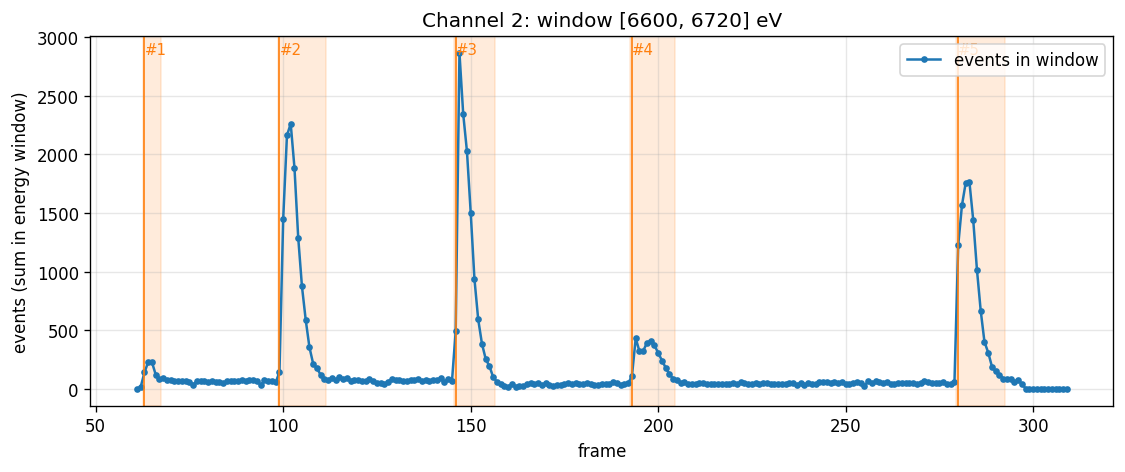

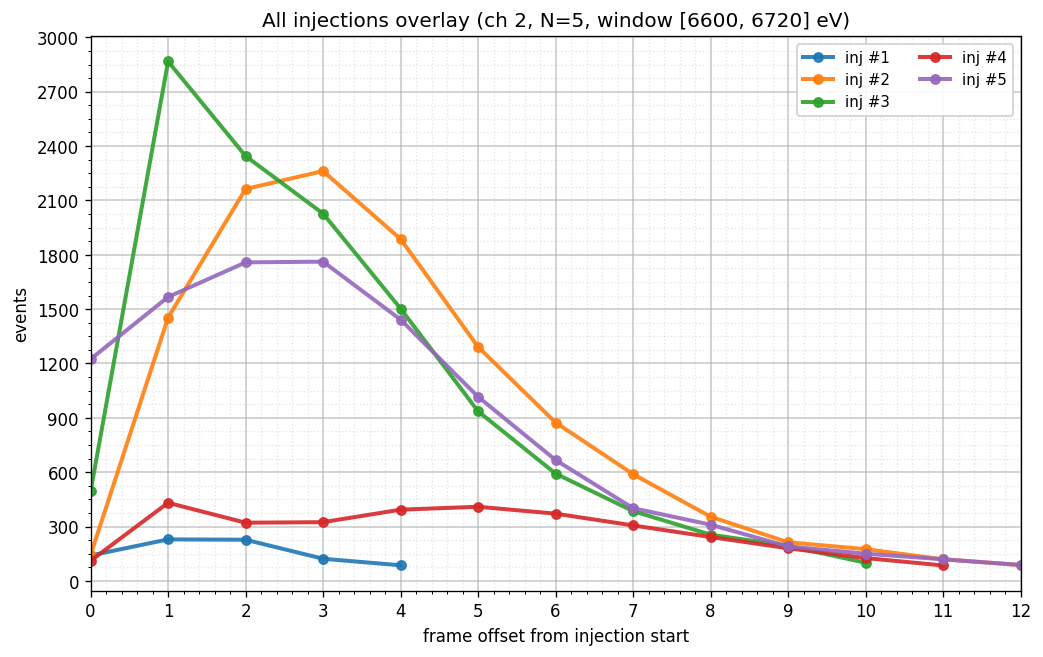

fit_injection: requested end index 81 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 82 exceeds len(fn)=80; clipping to 80
fit_injection: requested end index 83 exceeds len(fn)=80; clipping to 80

Multi-discharge summary (channel 2):
10-19: ch2 injections=5
10-24: ch2 injections=4
10-42: ch2 injections=3
test: ch2 injections=5


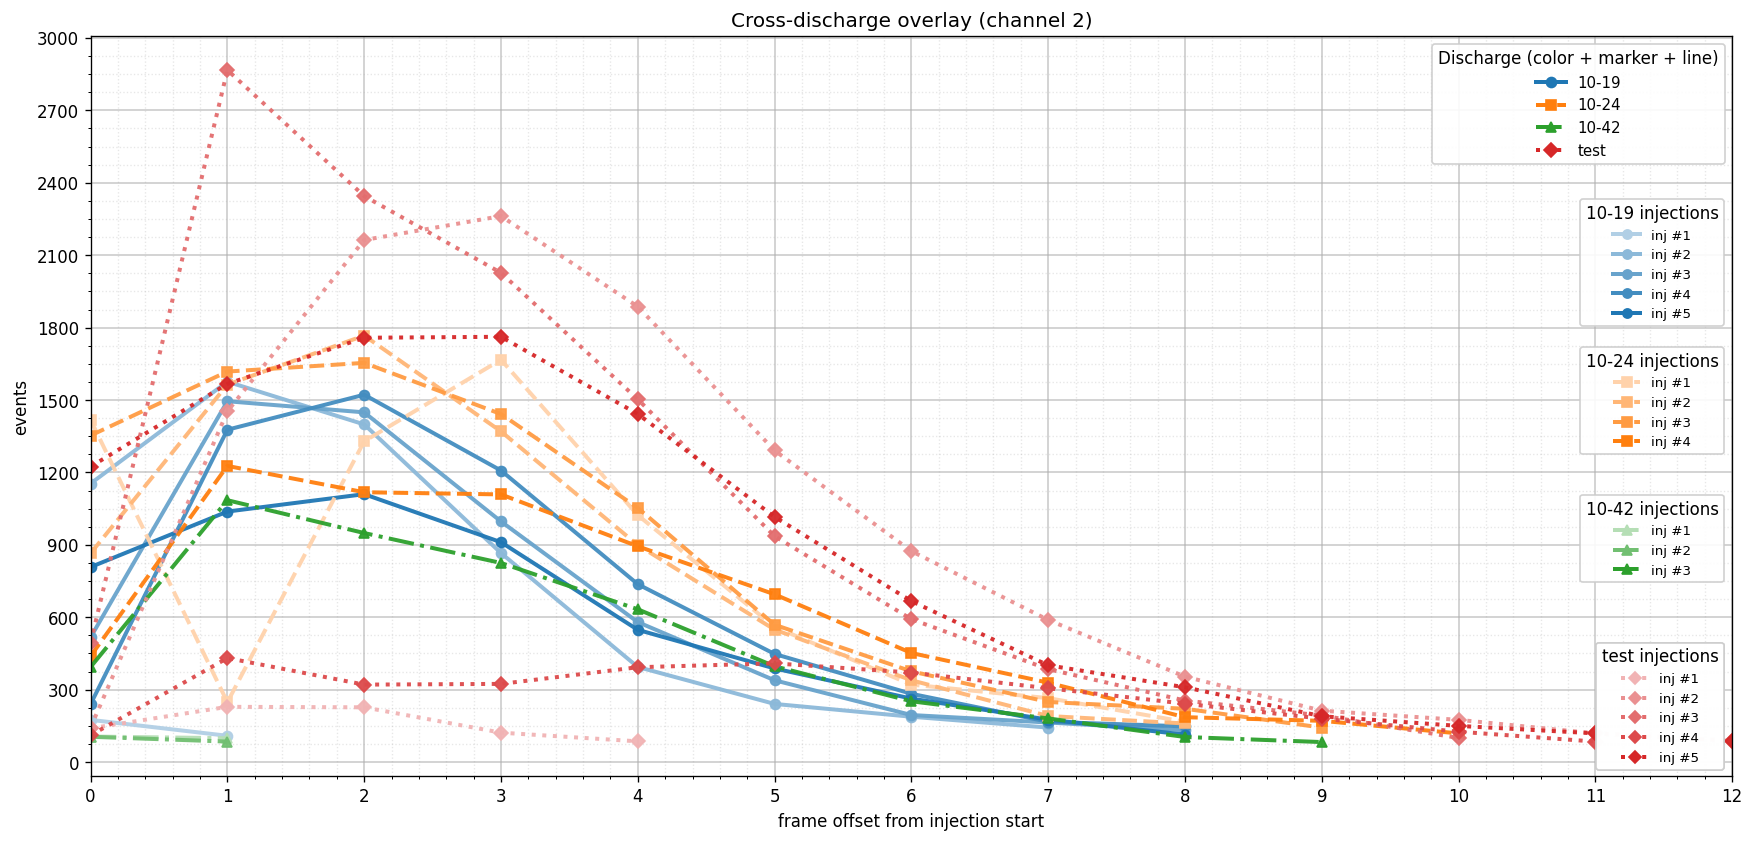

In [46]:
# --- Example usage (folder loading via pha_lib) ---
FOLDER_PATH = r"data\\test"
DISCHARGE = io.load_test_folder(FOLDER_PATH, discharge_id="XP_big_eye")

cfg = BigEyeConfig(
    line_energy_eV=6660.0,
    half_window_eV=60,
    n_points=3,
    adaptive_min_points=3,
    adaptive_max_points=15,
)

# Plain detector settings object (consumed by adaptive-points detector entrypoint).
detection_cfg = InjectionDetectionConfig(
    threshold_factor=2.0,
    min_jump=8.0,
    min_quiet_frames=1,
    min_separation_frames=2,
    max_frames_per_discharge=25,
)

result = run_big_eye(
    DISCHARGE,
    cfg=cfg,
    channel_ids=None,   # e.g. [1, 2]
    detection_cfg=detection_cfg,
    use_adaptive_fit=True,
)

print("detection source:", result["detection_source"])
print("fit source:", result["fit_source"])
summary_df = result["summary"]
summary_df.head(20)

# Quick diagnostics: how many injections were found per channel.
for ch, inj in result["detections"].items():
    print(f"ch {ch}: injections={len(inj)}")

# Global max offset (in frames) across all detected injections in all channels.
all_injections = [inj for inj_list in result["detections"].values() for inj in inj_list]
global_max_offset = max((inj.finish_frame - inj.start_frame for inj in all_injections), default=1)
print("global_max_offset:", global_max_offset)

# Pick channel 2 for visual diagnostics (fallback to first available channel).
channel_for_plot = 2 if 2 in result["traces"] else sorted(result["traces"].keys())[0]
trace = result["traces"][channel_for_plot]
injections = result["detections"][channel_for_plot]

fig, ax = plt.subplots(figsize=(11, 4))
plot_timetrace_with_injections(trace, injections, ax=ax)
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
plot_all_injections_one_graph(
    trace,
    injections,
    normalize_to_start=False,
    x_max_offset=global_max_offset,
    ax=ax,
)
plt.show()

# --- Multi-discharge overlay test on requested folders ---
multi_paths = {
    "10-19": r"data\\2025-04-29--10-19",
    "10-24": r"data\\2025-04-29--10-24",
    "10-42": r"data\\2025-04-29--10-42",
    "test": r"data\\test",
}

discharge_map = {
    name: io.load_test_folder(path, discharge_id=f"XP_{name}")
    for name, path in multi_paths.items()
}

results_by_discharge = {
    name: run_big_eye(
        d_obj,
        cfg=cfg,
        channel_ids=None,
        detection_cfg=detection_cfg,
        use_adaptive_fit=True,
    )
    for name, d_obj in discharge_map.items()
}

print("\nMulti-discharge summary (channel 2):")
for name, r in results_by_discharge.items():
    n_inj_ch2 = len(r["detections"].get(2, []))
    print(f"{name}: ch2 injections={n_inj_ch2}")

fig, ax = plt.subplots(figsize=(16, 8))
fig.subplots_adjust(right=0.98)
plot_injections_across_discharges(
    results_by_discharge,
    channel_id=2,
    injection_numbers=None,  # or e.g. [1, 2, 3]
    normalize_to_start=False,
    ax=ax,
    title="Cross-discharge overlay (channel 2)",
)
plt.show()